In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches


In [6]:
df_classified = pd.read_csv("../data/ouput/v2/classified_changesets_new_contribs_monthly.csv")

In [8]:
affiliations_ai = pd.read_csv("../data/ouput/v2/classified_affiliations_stats_ai_contributions.csv")

In [3]:
pd.options.display.float_format = '{:20,.2f}'.format

In [14]:
from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    'The two args are the value and tick position'
    return '%1.f million' % (x * 1e-6)


formatter = FuncFormatter(millions)
plain_formatter = FuncFormatter(lambda x, _: f"{int(x):,}")

Base Columns

    changeset_id - ID of the changeset
    edit_count - Number of edits in the changeset
    user_name - OSM contributor username
    year - Year of the changeset
    month - Month of the changeset

Enriched Columns (added by scripts/changeset_raw_data_to_data.py)

    created_by - Normalized editing software name
    device_type - Classification: desktop_editor, mobile_editor, tool, other
    bot - Boolean indicating if the changeset was made by a bot
    mid_pos_x, mid_pos_y - Discretized coordinates (0-360, 0-180)
    imagery_used - Array of imagery sources used
    hashtags - Array of hashtags from the changeset
    source - Array of data sources used
    mobile_os - Mobile OS detection (Android, iOS, or NULL)
    streetcomplete_quest - Normalized StreetComplete quest type
    all_tags - Array of all tag prefixes used
    organised_team - Organised team/corporation affiliation if applicable
    for_profit - Boolean indicating if the changeset was made by a for-profit organisation

In [4]:
df_new_contributors= pd.read_csv("../data/ouput/contribs_01/contributors_first_edit_software.csv").drop(columns={"Unnamed: 0"})
df_20 = df_new_contributors[df_new_contributors["first_edit_month"] > "2020-01"]

In [8]:
duckdb.sql("""
    SELECT
        organised_team,
        SUM(edit_count) AS total_edits   
    FROM db               
    WHERE year >= 2020
      AND bot = false
    GROUP BY organised_team
    ORDER BY total_edits DESC
""").show()

┌────────────────┬─────────────┐
│ organised_team │ total_edits │
│    varchar     │   int128    │
├────────────────┼─────────────┤
│ NULL           │  7996142161 │
│ Meta           │   215737797 │
│ Kaart          │   102473502 │
│ Apple          │    44868677 │
│ Amazon         │    39715820 │
│ TomTom         │    27777144 │
│ DigitalEgypt   │    23253569 │
│ Grab           │    17316929 │
│ Microsoft      │    14727879 │
│ Mapbox         │    12252565 │
│   ·            │         ·   │
│   ·            │         ·   │
│   ·            │         ·   │
│ Getpin         │       11810 │
│ GOAT           │        3707 │
│ DINAclub       │        2631 │
│ Komoot         │        2199 │
│ Digiroad       │        2112 │
│ WIGeoGIS       │        2109 │
│ Gojek          │        1328 │
│ TeleClinic     │         304 │
│ Blitzer.de     │         230 │
│ Balad          │          65 │
└────────────────┴─────────────┘
  50 rows (20 shown) 2 columns



organised team only for coproate groups - almost all for profit

In [16]:
duckdb.sql("""
    SELECT hashtags, SUM(edit_count) AS edits
    FROM db               
    WHERE year >= 2020
      AND bot = false
      AND array_to_string(hashtags, ',') ILIKE '%hotosm-project%'
    GROUP BY hashtags
    ORDER BY edits DESC
""").show()

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                                                  hashtags                                                                                   │  edits  │
│                                                                                  varchar[]                                                                                  │ int128  │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ [#hotosm-project-12597, #durbanfloods, #openmappinghub-esa]                                                                                                                 │ 5777239 │
│ [#hotosm-project-39210, #jubainfrastructuredigitization2026, #omdtz]

can get hotsom edits from hashtag filtering

In [9]:
df_new_contributors_old = duckdb.sql("""
    WITH user_first_changeset AS (
        SELECT
            user_name,
            year,
            month,
            created_by,
            hashtags,
            organised_team,
            source,
            ROW_NUMBER() OVER (
                PARTITION BY user_name 
                ORDER BY year, month, changeset_id
            ) as rn
        FROM db
    )
    SELECT
        user_name,
        CONCAT(year, '-', LPAD(CAST(month AS VARCHAR), 2, '0')) AS first_edit_month,
        CASE
            WHEN organised_team IS NOT NULL THEN 'organised_team'
            WHEN array_to_string(hashtags, ',') ILIKE '%hotosm-project%' 
            OR array_to_string(hashtags, ',') ILIKE '%missingmaps%'
            OR array_to_string(hashtags, ',') ILIKE '%missing-maps%' THEN 'humanitarian' 
            WHEN created_by = 'Rapid'
            OR array_to_string(source, ',') ILIKE '%microsoft/BuildingFootprints%'
            OR array_to_string(source, ',') ILIKE '%mapwithai%'
            OR array_to_string(source, ',') ILIKE '%esri/Google_Africa_Buildings%'
            OR array_to_string(source, ',') ILIKE '%esri/Google_Open_Buildings%' THEN 'AI'
            ELSE 'independent'
        END AS affiliation
    FROM user_first_changeset
    WHERE rn = 1 
    ORDER BY first_edit_month, user_name
""").df()

In [19]:
df_pivot = (
    df_new_contributors
    .groupby(['first_edit_month', 'affiliation'])
    .size()
    .unstack(fill_value=0)
    #.reset_index()
)

In [9]:
df_pivot["total"] = df_pivot["AI"] + df_pivot["humanitarian"]+ df_pivot["independent"]+ df_pivot["organised_team"]

In [20]:
df_pivot

affiliation,AI,humanitarian,independent,organised_team
first_edit_month,,,,
2005-04,0,0,4,0
2005-05,0,0,3,0
2005-06,0,0,4,0
2005-07,0,0,10,0
2005-08,0,0,11,0
...,...,...,...,...
2025-11,77,2222,13224,4
2025-12,33,1171,12164,3
2026-01,24,797,13470,1


In [18]:
# comparison number of total edits and nr of edits with hotsom hashtag
duckdb.sql("""
    SELECT SUM(edit_count) AS HOTedits
    FROM db               
    WHERE year >= 2020
      AND bot = false
      AND array_to_string(hashtags, ',') ILIKE '%hotosm-project%'

""").show()

┌───────────┐
│ HOTedits  │
│  int128   │
├───────────┤
│ 911796549 │
└───────────┘



In [24]:
# comparison number of total edits and nr of edits with hotsom hashtag
duckdb.sql("""
    SELECT SUM(edit_count) AS edits
    FROM db               
    WHERE year >= 2020
""").show()

┌────────────┐
│   edits    │
│   int128   │
├────────────┤
│ 8623208311 │
└────────────┘



In [26]:
(911796549 / 8623208311  ) *100

10.573750698297378

quick overview: around 10% of all edits since 2020 with hot hashtag

In [23]:
# comparison number of total edits and nr of edits with hotsom hashtag
duckdb.sql("""
    SELECT SUM(edit_count) AS BotEdits
    FROM db               
    WHERE year >= 2020
      AND bot = true

""").show()

┌──────────┐
│ BotEdits │
│  int128  │
├──────────┤
│ 76259886 │
└──────────┘



In [27]:
(76259886 /8623208311)*100

0.8843563004586217

0,8% of edits from bots

In [34]:
# comparison number of total edits and nr of edits with hotsom hashtag
duckdb.sql("""
    SELECT SUM(edit_count) AS OrganisedEdits
    FROM db               
    WHERE year >= 2020
      AND organised_team NOT NULL
      AND bot = false
      """).show()

┌────────────────┐
│ OrganisedEdits │
│     int128     │
├────────────────┤
│      550806264 │
└────────────────┘



In [30]:
(550806264  /8623208311)*100

6.387486468318021

around 6% of edits from known corporate teams

In [33]:
df_20

,user_name,first_edit_month,created_by
1434663,$DA,2020-02,iD
1434664,$ondre,2020-02,iD
1434665,(株)アイワテクノ,2020-02,iD
1434666,+Yan,2020-02,iD
1434667,-------------------------,2020-02,iD
...,...,...,...
2453323,현우20,2026-03,Pic4Review
2453324,흥선군,2026-03,iD
2453325,𓇼 Marcela Dolejsi 𓇼,2026-03,AED Map
2453326,🏠منزل أبو فلاح,2026-03,MAPS.ME


### Affiliation New Contributors

#### Creating and Downlaoding classified_changesets_new_contribs_monthly 


In [2]:
new_contribs = pd.read_csv(r"../data/ouput/new_contribs.csv").drop(columns={"Unnamed: 0"})

In [4]:
db = duckdb.read_parquet(r"/data/input/piebro/changeset_data/year=*/month=*/*.parquet", hive_partitioning=1) 

In [5]:
df_classified = duckdb.sql("""
    WITH lists AS (
        SELECT
            ['amap', 'adt', 'bolt', 'DigitalEgypt', 'expedia', 'gojek', 'MSFTOpenMaps', 'grab',
             'Kaart', 'Kontur', 'mbx', 'RocketData', 'disputed_by_claimed_by', 'Snapp', 'stackbox',
             'Telenav', 'Lightcyphers', 'tomtom', 'TIDBO', 'WIGeoGIS-OMV', 'نشان', 'mapbox',
             'Komoot', 'AppLogica'] AS corporate_hashtags
    ),
    classified AS (
        SELECT
            d.user_name,
            d.changeset_id,
            CONCAT(d.year, '-', LPAD(CAST(d.month AS VARCHAR), 2, '0')) AS months,
            year,
            (
                d.created_by = 'Rapid'
                OR array_to_string(d.source, ',') ILIKE '%mapwithai%'
                OR array_to_string(d.source, ',') ILIKE '%esri/Google_Africa_Buildings%'
                OR array_to_string(d.source, ',') ILIKE '%esri/Google_Open_Buildings%'
                OR array_to_string(d.hashtags, ',') ILIKE '%mapwithai%'
            ) AS is_AI,
            list_has_any(
                list_transform(d.hashtags, h -> lower(h)),
                list_transform(l.corporate_hashtags, x -> lower(x))
            ) AS is_corporate,
            (
                array_to_string(d.hashtags, ',') ILIKE '%hotosm-project-%'
                OR array_to_string(d.hashtags, ',') ILIKE '%missing_maps%'
                OR array_to_string(d.hashtags, ',') ILIKE '%missingmaps%'
            ) AS is_humanitarian
        FROM db d, lists l
        WHERE d.user_name IN (SELECT user_name FROM new_contribs) AND d.changeset_id IN (SELECT changeset_id FROM new_contribs)
    )
    SELECT 
    year,
    months,
    CAST(COUNT(*) AS INTEGER) AS Changesets,
    CAST(COUNT(CASE WHEN is_corporate THEN 1 END) AS INTEGER) AS Changesets_corporate,
    CAST(COUNT(CASE WHEN is_humanitarian THEN 1 END) AS INTEGER) AS Changesets_humanitarian,
    CAST(COUNT(CASE WHEN is_AI THEN 1 END) AS INTEGER) AS Changesets_AI,
    FROM classified
    GROUP BY year, months
    ORDER BY months 

""").df()

RuntimeError: Query interrupted

In [50]:
df_classified.to_csv("../data/ouput/v2/classified_changesets_new_contribs_monthly.csv")

## Plot

In [18]:
affiliations_ai

,Unnamed: 0,year,months,Contributors,Edits,Changesets,Contributors_organised_team,Edits_organised_team,Changesets_organised_team,Contributors_humanitarian,Edits_humanitarian,Changesets_humanitarian
0,0,2019,2019-08,283,1133906,15170,13,548238,8924,2,71,4
1,1,2019,2019-05,31,6016,96,0,0,0,0,0,0
2,2,2019,2019-12,358,3235524,17768,6,25134,229,62,590964,1421
3,3,2019,2019-11,316,2908673,22865,1,30,1,77,347068,3878
4,4,2019,2019-10,285,3158247,21975,5,8268,49,30,133590,2125
...,...,...,...,...,...,...,...,...,...,...,...,...
78,78,2025,2025-06,658,4084116,18675,11,113053,618,37,123133,593
79,79,2025,2025-09,598,5580667,37432,6,25324,386,9,5838,50
80,80,2026,2026-03,635,5844978,40866,37,358345,2714,27,311111,888
81,81,2026,2026-01,567,5236901,33593,7,28358,443,12,2983,30


In [21]:
df_AI_20 = affiliations_ai[(affiliations_ai["year"] > 2019) & (affiliations_ai["year"] <= 2026)]
df_aff_ai = df_AI_20[["months","Changesets", "Changesets_organised_team", "Changesets_humanitarian"]].copy()

In [24]:
df_aff_ai = df_aff_ai.sort_values(by="months")

In [10]:
df_aff_contirb = df_classified[(df_classified["months"] >= "2020-01") & (df_classified["months"] <= "2025-12")]

In [40]:
def show_every_nth_ticklabel(ax, n=12, long_len=10, short_len=3.5, pad=2):
    for i, tick in enumerate(ax.xaxis.get_major_ticks()):
        show = (i % n == 0)
        tick.label1.set_visible(show)
        tick.tick1line.set_visible(True)
        tick.tick1line.set_markersize(long_len if show else short_len)
        if show:
            tick.set_pad(pad)

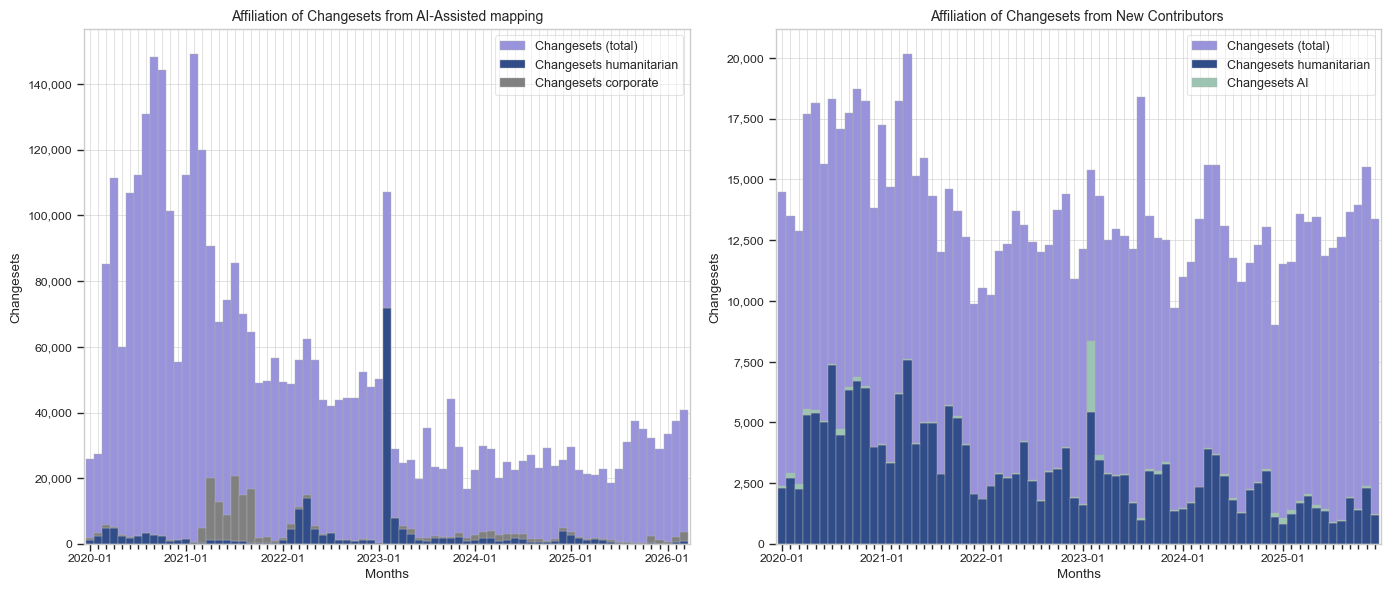

In [55]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper")

#combined graph
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax1 = ax[0]
ax1.set_title("Affiliation of Changesets from AI-Assisted mapping", fontsize=10)    

df_aff_ai.set_index('months')['Changesets'].plot(
    kind='bar',
    stacked=True,
    color=['#9893DA'],  
    edgecolor="0.7", 
    linewidth=0.3,
    width=1.0,
    ax = ax1,
    rot=0,
    )
df_aff_ai.set_index('months')[['Changesets_humanitarian', "Changesets_organised_team"]].plot(
    kind='bar',
    stacked=True,
    color=['#304C89','grey'],  
    edgecolor="0.7", 
    linewidth=0.3,
    width=1.0,
    ax = ax1,
    rot=0,
    )

ax1.yaxis.set_major_formatter(plain_formatter)
ax1.set_xlabel('Months')
ax1.set_ylabel('Changesets')
ax1.set_ylim(0,)
ax1.legend(['Changesets (total)', 'Changesets humanitarian', 'Changesets corporate'], fontsize = 9,frameon=True, facecolor="w", framealpha = 0.5) 
ax1.grid(lw='0.4')


ax2 = ax[1]
ax2.set_title("Affiliation of Changesets from New Contributors ", fontsize=10)    
df_aff_contirb.set_index('months')['Changesets'].plot(
    kind='bar',
    stacked=True,
    color=['#9893DA'],  
    edgecolor="0.7", 
    linewidth=0.3,
    width=1.0,
    ax = ax2,
    rot=0,
    )

df_aff_contirb.set_index('months')[['Changesets_humanitarian', "Changesets_AI"]].plot(
    kind='bar',
    stacked=True,
    color=['#304C89','#9CC4B2'],  
    edgecolor="0.7", 
    linewidth=0.3,
    width=1.0,
    ax = ax2,
    rot=0,
    )
ax2.set_xlabel('Months')
ax2.set_ylabel('Changesets')
ax2.set_ylim(0,)
ax2.legend(['Changesets (total)', 'Changesets humanitarian', 'Changesets AI'], fontsize = 9, frameon=True, facecolor="w", framealpha = 0.5) 
ax2.grid(lw='0.4')
ax2.yaxis.set_major_formatter(plain_formatter)

show_every_nth_ticklabel(ax1)
show_every_nth_ticklabel(ax2)

fig.savefig("../results/affiliation_ai_new_contributor_changesets_vn1.png", bbox_inches="tight", dpi=300)

fig.tight_layout()
plt.show()

In [25]:
df_new_contribs_20 = df_new_contributors[df_new_contributors["first_edit_month"] >= "2020-01"]
df_pivot20 = (
    df_new_contribs_20
    .groupby(['first_edit_month', 'affiliation'])
    .size()
    .unstack(fill_value=0)
    #.reset_index()
)


In [32]:
df_pivot20_small = df_pivot20[["AI", "organised_team"]]

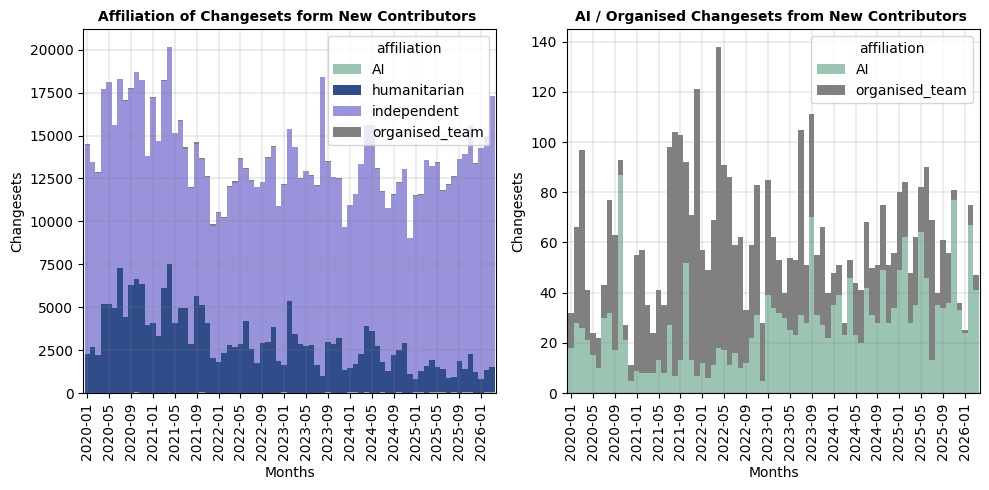

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax1 = ax[0] 
df_pivot20.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    color=["#9CC4B2", '#304C89', '#9893DA', "grey"],  # matches column order below
    edgecolor='none',
    width=1.0,
    ax=ax1
    )
ticks = ax1.get_xticks()
labels = [lbl.get_text() for lbl in ax1.get_xticklabels()]
ax1.set_xticks(ticks[::4])
ax1.set_xticklabels(labels[::4], rotation=90)
ax1.set_title("Affiliation of Changesets form New Contributors ", fontsize=10, fontweight="bold")    
ax1.grid(linewidth=0.2, color = "gray")
ax1.set_xlabel('Months')
ax1.set_ylabel('Changesets')
ax1.set_ylim(0,)

ax2 = ax[1] 
df_pivot20_small.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    color=["#9CC4B2", "grey"],  
    edgecolor='none',
    width=1.0,
    ax=ax2
    )
ticks = ax2.get_xticks()
labels = [lbl.get_text() for lbl in ax2.get_xticklabels()]
ax2.set_xticks(ticks[::4])
ax2.set_xticklabels(labels[::4], rotation=90)
ax2.set_title("AI / Organised Changesets from New Contributors ", fontsize=10, fontweight="bold")    
ax2.grid(linewidth=0.2, color = "gray")
ax2.set_xlabel('Months')
ax2.set_ylabel('Changesets')
ax2.set_ylim(0,)

fig.tight_layout()

fig.savefig("../results/affiliation_for_first_edit_v2.png", bbox_inches="tight")
